<a href="https://colab.research.google.com/github/gianlucamajor/eCruziDB/blob/main/eda/differential-reactivity-PE-by-clinical-groups-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab-**eCruzidb** Extended Data Analysis
## Differential Reactivity of predicted epitope (PE) across clinical groups EDA




In [73]:
#@title Input parameters, then hit `Runtime` -> `Run all`

# Define what constitutes a "Potential Biomarker"

#@markdown 1. High Reactivity (Dashad red line)
high_reactivity_threshold = 3 #@param {type:"number"}
#@markdown 2. Basal Reactivity(Dashad gray line)
basal_reactivity_threshold = 0 #@param {type:"number"}

In [74]:
#@title Install dependencies and loading libs
%time
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.stats import zscore


CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.63 µs


In [75]:
#@title Download data from eCruzidb
# The authority will not require after eCruzidb became open
%time
PE_json_url = "https://projetos.lbi.iq.usp.br/trypanosoma/ecruzidb/data/epitopes-data.json"
user = "ecruzidb"
password = "setulab"

response = requests.get(PE_json_url, auth=(user, password))
if response.status_code == 200:
    data = response.json()
    PEs_df = pd.DataFrame(data)
else:
    print(f"Failed to fetch data: {response.status_code}")

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.25 µs


In [76]:
#@title Prepare dataframe
# List of Predicted Epitopes
# Define the list of columns for each group of patients
%time
new_group_columns = [
    'control_a', 'control_b', 'asympto_a', 'asympto_b',
    'CCC_mild_a', 'CCC_mild_b', 'CCC_severe_a', 'CCC_severe_b'
]

def join_replicates(row):
  row['control'] = row['control_a'] + row['control_b']
  row['asymptomatic'] = row['asympto_a'] + row['asympto_b']
  row['CCC_mild'] = row['CCC_mild_a'] + row['CCC_mild_b']
  row['CCC_severe'] = row['CCC_severe_a'] + row['CCC_severe_b']
  return row


# Iterate through the column names and extract values from the dictionary;
# when there is no info about group the column get 0 (zero) as a value.
for col_name in new_group_columns:
    PEs_df[col_name] = PEs_df['Number of Inserts by Group'].apply(lambda x: x.get(col_name, 0))

PEs_df = PEs_df.apply(lambda row: join_replicates(row), axis=1)

# Remove it because it is no longer needed
PEs_df = PEs_df.drop(columns=new_group_columns)

# Calculating Z-scores
PEs_df['zs-control'] = zscore(PEs_df['control'])
PEs_df['zs-asymptomatic'] = zscore(PEs_df['asymptomatic'])
PEs_df['zs-CCC_mild'] = zscore(PEs_df['CCC_mild'])
PEs_df['zs-CCC_severe'] = zscore(PEs_df['CCC_severe'])

# Adjusting dataframe
PEs_zs_df = PEs_df[['ID','Epitope', 'zs-control', 'zs-asymptomatic', 'zs-CCC_mild', 'zs-CCC_severe']].copy()
PEs_zs_df = PEs_zs_df.rename(columns={'zs-control': 'Control', 'zs-asymptomatic': 'Asymptomatic', 'zs-CCC_mild': 'CCC Mild', 'zs-CCC_severe': 'CCC Severe'})

# Creating melted dataframe
PEs_zs_melted_df = PEs_zs_df.melt(id_vars=['ID','Epitope'], var_name='Z-score Type', value_name='Z-score')
PEs_zs_melted_df['Epitope'] = PEs_zs_melted_df['Epitope'].astype('category')



CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 5.72 µs


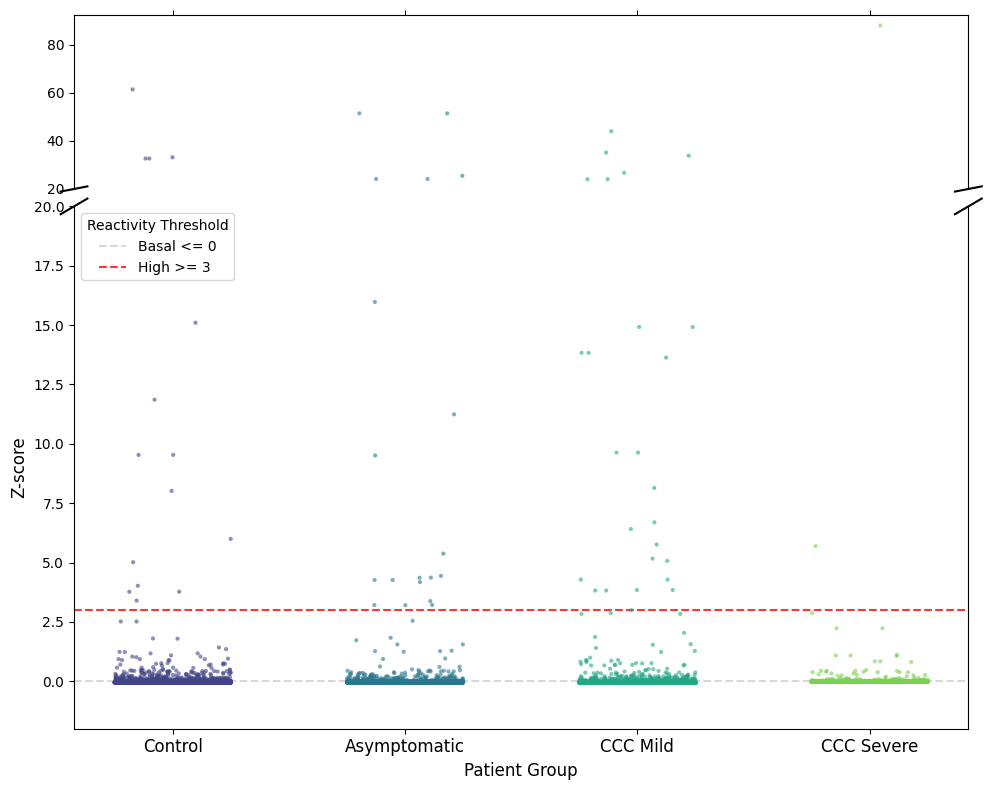

In [77]:
#@title Differential reactivity of predicted epitopes across clinical groups
# --- CONFIGURATION ---
break_point = 20  # Where the axis splits
ylim_bottom = (-2, break_point) # Range for the bottom 75% (includes small negatives)
# Calculate max for top limit automatically, adding some headroom
ylim_top = (break_point, PEs_zs_melted_df['Z-score'].max() * 1.05)

plt.figure(figsize=(10, 8))

# --- GRID SETUP ---
# height_ratios=[1, 3] means the top plot is 1 unit high, bottom is 3 units high (25% vs 75%)
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3])

ax_top = plt.subplot(gs[0])
ax_bottom = plt.subplot(gs[1], sharex=ax_top)

# --- PLOTTING ---
# We plot the SAME data on both axes
kwargs = dict(x='Z-score Type', y='Z-score', data=PEs_zs_melted_df,
              palette='viridis', jitter=0.25, size=3, alpha=0.6, hue='Z-score Type', legend=False)

sns.stripplot(**kwargs, ax=ax_top)
sns.stripplot(**kwargs, ax=ax_bottom)

# --- AXIS LIMITS (The "Zoom") ---
ax_bottom.set_ylim(*ylim_bottom)  # 75% of space for -2 to 20
ax_top.set_ylim(*ylim_top)        # 25% of space for 20 to Max

# --- COSMETICS (Hiding Spines) ---
# Hide the bottom spine of the top plot and top spine of the bottom plot
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)

# Remove x-axis ticks/labels from the top plot
ax_top.xaxis.tick_top()
ax_top.tick_params(labeltop=False)
ax_bottom.xaxis.tick_bottom()
ax_bottom.tick_params(axis='x', labelsize=12) # Set font size for x-axis tick labels

# --- DIAGONAL CUT LINES (The "Break" Effect) ---
d = .015  # Size of the diagonal lines
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)        # Top-left diagonal
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax_bottom.transAxes)  # Switch to bottom axes
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# --- LABELS & TITLES ---
# ax_top.set_title('Global profile of differential immunoreactivity of predicted epitopes across clinical groups.', fontsize=14, fontweight='bold')
ax_top.set_xlabel('')
ax_top.set_ylabel('')

ax_bottom.set_xlabel('Patient Group', fontsize=12)
ax_bottom.set_ylabel('Z-score', fontsize=12)

# Add a reference line at 0 (only needed on the bottom plot)
basal_threshold_lable = f"Basal <= {basal_reactivity_threshold}"
ax_bottom.axhline(basal_reactivity_threshold, color='gray', linestyle='--', alpha=0.3, label=basal_threshold_lable)

# Threshold boxe (Visual guide)
high_threshold_lable = f"High >= {high_reactivity_threshold}"
ax_bottom.axhline(high_reactivity_threshold, color='red', linestyle='--', alpha=0.8, label=high_threshold_lable)
ax_bottom.legend(title="Reactivity Threshold")

plt.tight_layout()
plt.subplots_adjust(hspace=0.05) # Overlap slightly to make the connection look better
plt.show()

In [78]:
#@title List of all predicted epitopes high reactivity at least one clinical or control group
reactivity_Control_df = PEs_zs_df[(PEs_zs_df['Control'] >= high_reactivity_threshold)]
reactivity_Asympt_df = PEs_zs_df[(PEs_zs_df['Asymptomatic'] >= high_reactivity_threshold)]
reactivity_CCC_mild_df = PEs_zs_df[(PEs_zs_df['CCC Mild'] >= high_reactivity_threshold)]
reactivity_CCC_severe_df = PEs_zs_df[(PEs_zs_df['CCC Severe'] >= high_reactivity_threshold)]


reactivity_PEs = pd.concat(
     [reactivity_Control_df, reactivity_Asympt_df, reactivity_CCC_mild_df, reactivity_CCC_severe_df], axis=0
)
reactivity_PEs

,ID,Epitope,Control,Asymptomatic,CCC Mild,CCC Severe
16,20-0,SRCQQTPP,11.860110,3.377210,6.691884,1.069268
17,21-0,GQQAQPHS,8.016016,3.212303,5.072198,0.806577
420,392-0,TRREGSRPS,32.680669,4.264595,9.630720,0.839470
421,392-1,RDGTRHHHH,32.680669,4.264595,9.630720,0.839470
612,573-0,ETKAPPQSPCCDKRAGNAGGLAPHFRFGRPDR,3.768506,1.551700,4.281281,0.399156
...,...,...,...,...,...,...
5234,4908-0,VQASRLRGSSPPGGAGEEKEGSEEKKRKDRKENEKQTNKKQNQQLK...,33.163605,-0.010305,5.166259,0.382483
5367,5034-0,HPSPSAAQHSLPRRHPSP,15.099079,5.375701,6.409700,1.107152
6514,6136-0,AMGEAGGRSWSNVVKSPHSP,-0.044556,-0.041442,13.632905,-0.016205
1364,1264-0,QHSLPRRHPSPSAAQH,61.404700,25.467849,33.854320,5.691660
